# 0. Imports and inputs

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# define the directory to the mismatch results
mismatch_results_dir = r"C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\24_09_24_Solar_Edge\Results\25_11_14_results.xlsx"

# define the plot template
axis_label_size = 20
axis_num_size = 20
text_size = 20
title_size = 22

# define the figure size for single plot
figure_size = (6, 6)
subplot_size_1_2 = (6, 6)
long_hoz_figsize = (12, 6)

# 1. Plots

## 1.1. Plot against season

### 1.1.1. Filter with shading or orientation

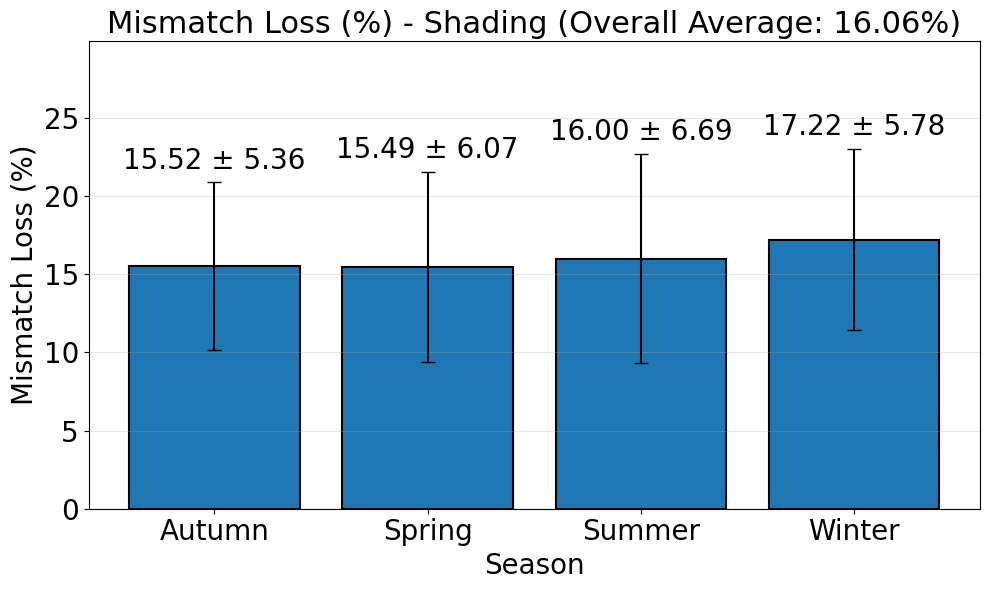

In [11]:
# load the excel file from the mismatch results directory
mismatch_results = pd.read_excel(mismatch_results_dir, sheet_name='Multi strings')

# only read the data with single orientation
# single_orientation_results = mismatch_results[mismatch_results['Orientation'] == 'Single']
single_orientation_results = mismatch_results

# determine whether shading or noshading
shading_only = True

# only keep the results whose Shading column is No
if shading_only:
    no_shading_results = single_orientation_results[single_orientation_results['Shading'] == 'Yes']
    shading_status = 'Shading'
else:
    no_shading_results = single_orientation_results[single_orientation_results['Shading'] == 'No']
    shading_status = 'No Shading'

# calculate the average value of the column Spring mismatch	Summer mismatch	Autumn mismatch	Winter mismatch
average_mismatch = no_shading_results[['Spring mismatch', 'Summer mismatch', 'Autumn mismatch', 'Winter mismatch']].mean()

# calculate the standard deviation of the column Spring mismatch	Summer mismatch	Autumn mismatch	Winter mismatch
standard_deviation_mismatch = no_shading_results[['Spring mismatch', 'Summer mismatch', 'Autumn mismatch', 'Winter mismatch']].std()

# calculate overall average across all seasons and all systems
overall_average = no_shading_results[['Spring mismatch', 'Summer mismatch', 'Autumn mismatch', 'Winter mismatch']].values.mean()

# reorder to match the desired order: Autumn, Spring, Summer, Winter
season_order = ['Autumn mismatch', 'Spring mismatch', 'Summer mismatch', 'Winter mismatch']
average_mismatch = average_mismatch[season_order]
standard_deviation_mismatch = standard_deviation_mismatch[season_order]

# create season labels without "mismatch" suffix
season_labels = [s.replace(' mismatch', '') for s in season_order]

# plot the average as barchart and std as error bar
plt.figure(figsize=(10, 6))
bars = plt.bar(season_labels, average_mismatch.values, yerr=standard_deviation_mismatch.values, 
               capsize=5, edgecolor='black', linewidth=1.5)

# add labels above each bar showing mean ± std
for i, (mean_val, std_val) in enumerate(zip(average_mismatch.values, standard_deviation_mismatch.values)):
    label_text = f'{mean_val:.2f} ± {std_val:.2f}'
    plt.text(i, mean_val + std_val + 0.5, label_text, 
             ha='center', va='bottom', fontsize=text_size)

# set labels and title with appropriate font sizes
plt.xlabel('Season', fontsize=axis_label_size)
plt.ylabel('Mismatch Loss (%)', fontsize=axis_label_size)
plt.title(f'Mismatch Loss (%) - {shading_status} (Overall Average: {overall_average:.2f}%)', fontsize=title_size)

# set tick label font sizes
plt.xticks(fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)

# add grid
plt.grid(True, alpha=0.3, axis='y')

# set y-axis limits to accommodate labels
plt.ylim(0, max(average_mismatch.values + standard_deviation_mismatch.values) * 1.3)

plt.tight_layout()
plt.show()


### 1.1.2. All data

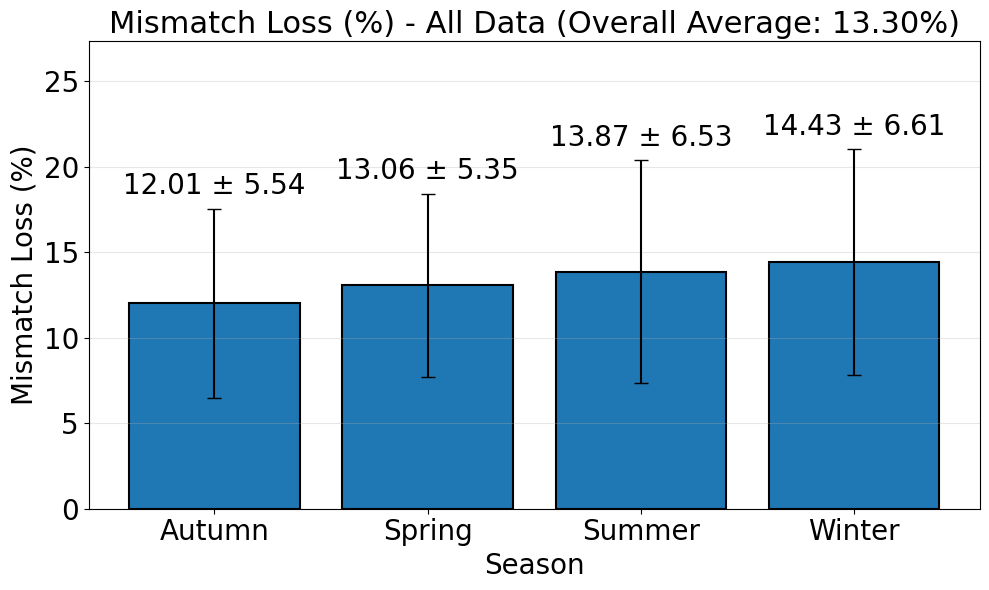

In [4]:
# load the excel file from the mismatch results directory
mismatch_results = pd.read_excel(mismatch_results_dir, sheet_name='Multi strings')

# include all data regardless of orientation or shading
all_results = mismatch_results.copy()

# set shading status for title
shading_status = 'All Data'

# convert mismatch columns to numeric, coercing errors to NaN
mismatch_cols = ['Spring mismatch', 'Summer mismatch', 'Autumn mismatch', 'Winter mismatch']
for col in mismatch_cols:
    all_results[col] = pd.to_numeric(all_results[col], errors='coerce')

# also convert 'Mean mismatch' column to numeric if it exists
if 'Mean mismatch' in all_results.columns:
    all_results['Mean mismatch'] = pd.to_numeric(all_results['Mean mismatch'], errors='coerce')

# calculate the average value of the column Spring mismatch	Summer mismatch	Autumn mismatch	Winter mismatch
average_mismatch = all_results[mismatch_cols].mean()

# calculate the standard deviation of the column Spring mismatch	Summer mismatch	Autumn mismatch	Winter mismatch
standard_deviation_mismatch = all_results[mismatch_cols].std()

# calculate overall average across all seasons and all systems
# use 'Mean mismatch' column if available, otherwise calculate from seasonal columns
if 'Mean mismatch' in all_results.columns:
    overall_average = all_results['Mean mismatch'].mean()
else:
    overall_average = all_results[mismatch_cols].values.mean()

# reorder to match the desired order: Autumn, Spring, Summer, Winter
season_order = ['Autumn mismatch', 'Spring mismatch', 'Summer mismatch', 'Winter mismatch']
average_mismatch = average_mismatch[season_order]
standard_deviation_mismatch = standard_deviation_mismatch[season_order]

# create season labels without "mismatch" suffix
season_labels = [s.replace(' mismatch', '') for s in season_order]

# plot the average as barchart and std as error bar
plt.figure(figsize=(10, 6))
bars = plt.bar(season_labels, average_mismatch.values, yerr=standard_deviation_mismatch.values, 
               capsize=5, edgecolor='black', linewidth=1.5)

# add labels above each bar showing mean ± std
for i, (mean_val, std_val) in enumerate(zip(average_mismatch.values, standard_deviation_mismatch.values)):
    label_text = f'{mean_val:.2f} ± {std_val:.2f}'
    plt.text(i, mean_val + std_val + 0.5, label_text, 
             ha='center', va='bottom', fontsize=text_size)

# set labels and title with appropriate font sizes
plt.xlabel('Season', fontsize=axis_label_size)
plt.ylabel('Mismatch Loss (%)', fontsize=axis_label_size)
plt.title(f'Mismatch Loss (%) - {shading_status} (Overall Average: {overall_average:.2f}%)', fontsize=title_size)

# set tick label font sizes
plt.xticks(fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)

# add grid
plt.grid(True, alpha=0.3, axis='y')

# set y-axis limits to accommodate labels
plt.ylim(0, max(average_mismatch.values + standard_deviation_mismatch.values) * 1.3)

plt.tight_layout()
plt.show()


## 1.2. Overall histogram

### 1.2.1. One string for single orientation

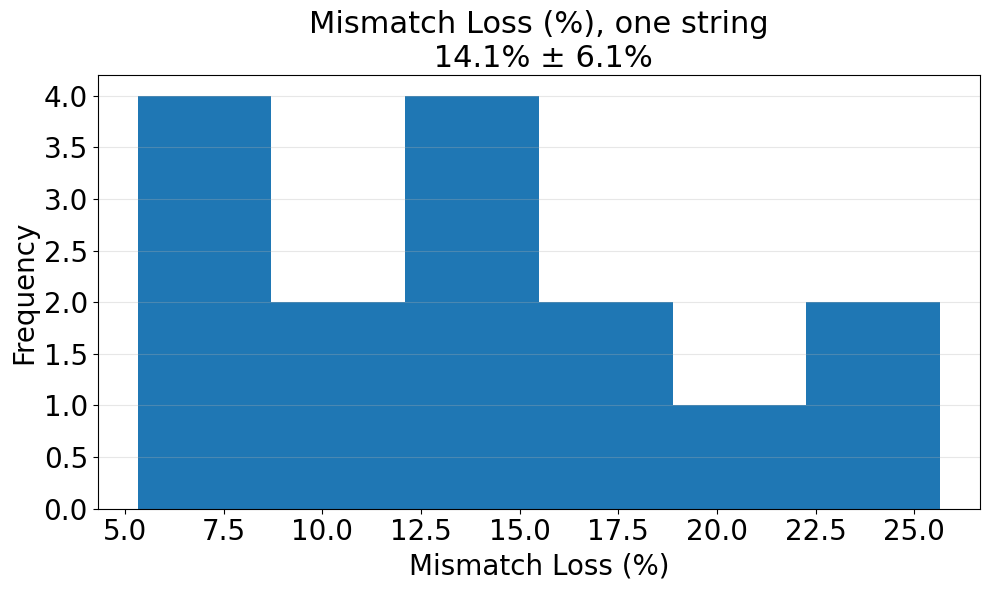

In [5]:
# load the excel file from the mismatch results directory
mismatch_results = pd.read_excel(mismatch_results_dir, sheet_name='Single strings')

# only read the data with single orientation
if 'Orientation' in mismatch_results.columns:
    mismatch_results = mismatch_results[mismatch_results['Orientation'] == 'Single']

# convert 'Mean mismatch' column to numeric, coercing errors to NaN
mismatch_results['Mean mismatch'] = pd.to_numeric(mismatch_results['Mean mismatch'], errors='coerce')

# drop NaN values for plotting
mean_mismatch_clean = mismatch_results['Mean mismatch'].dropna()

# calculat the mean and std
mean_mismatch = round(mean_mismatch_clean.mean(),1)
std_mismatch = round(mean_mismatch_clean.std(),1)

# plot a histogram of the Mean mismatch column
plt.figure(figsize=(10, 6))
plt.hist(mean_mismatch_clean, bins=6)
plt.xlabel('Mismatch Loss (%)', fontsize=axis_label_size)
plt.ylabel('Frequency', fontsize=axis_label_size)
plt.title(f'Mismatch Loss (%), one string\n {mean_mismatch:.1f}% ± {std_mismatch:.1f}%', fontsize=title_size)
plt.xticks(fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 1.2.2. Both single and multi orientation for single string

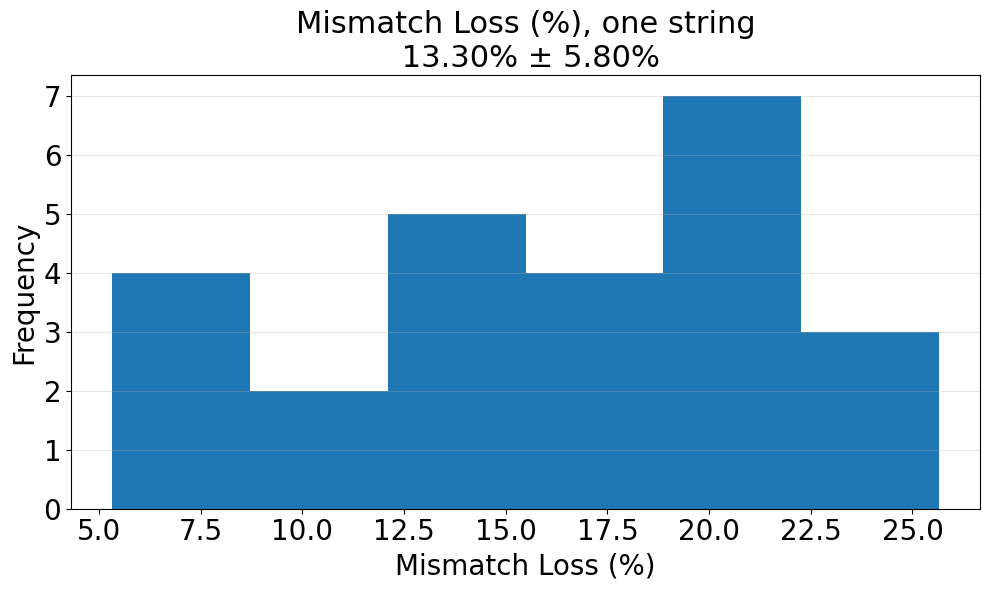

In [6]:
# load the excel file from the mismatch results directory
mismatch_results = pd.read_excel(mismatch_results_dir, sheet_name='Single strings')

# convert 'Mean mismatch' column to numeric, coercing errors to NaN
mismatch_results['Mean mismatch'] = pd.to_numeric(mismatch_results['Mean mismatch'], errors='coerce')

# drop NaN values for plotting
mean_mismatch_clean = mismatch_results['Mean mismatch'].dropna()

# calculat the mean and std
mean_mismatch = round(mean_mismatch_clean.mean(),1)
std_mismatch = round(mean_mismatch_clean.std(),1)

# plot a histogram of the Mean mismatch column
plt.figure(figsize=(10, 6))
plt.hist(mean_mismatch_clean, bins=6)
plt.xlabel('Mismatch Loss (%)', fontsize=axis_label_size)
plt.ylabel('Frequency', fontsize=axis_label_size)
# plt.title('Mismatch Loss (%) for one string/' + str(mean_mismatch) + ' ± ' + str(std_mismatch) + '%', fontsize=title_size)
plt.title(f'Mismatch Loss (%), one string\n {overall_average:.2f}% ± {std_mismatch:.2f}%', fontsize=title_size)
plt.xticks(fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 1.2.3. Multi string for multi orientation

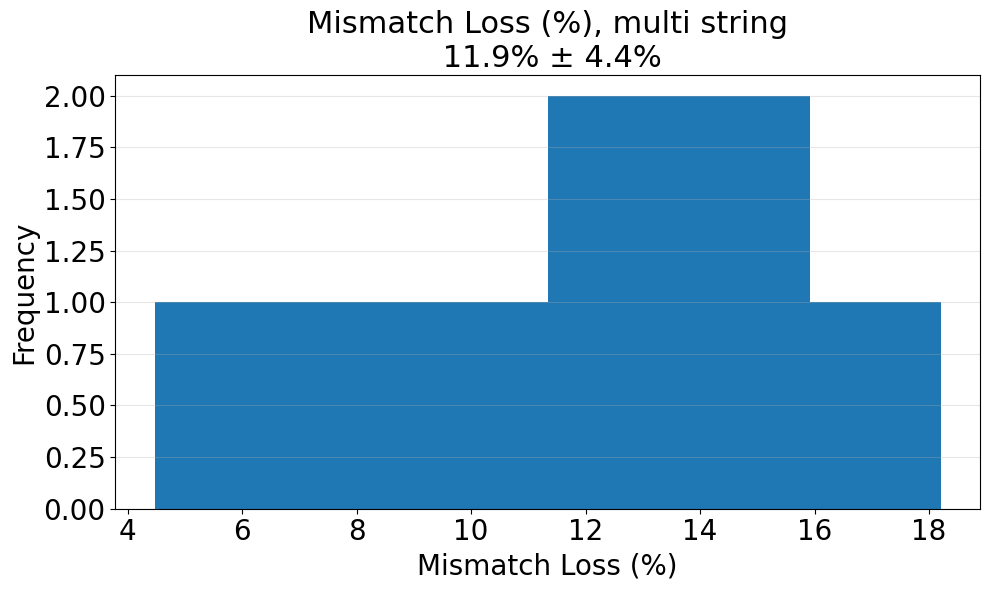

In [7]:
# load the excel file from the mismatch results directory
mismatch_results = pd.read_excel(mismatch_results_dir, sheet_name='Multi strings')

# only read the data with multi orientation
if 'Orientation' in mismatch_results.columns:
    mismatch_results = mismatch_results[mismatch_results['Orientation'] == 'Multi']

# convert 'Mean mismatch' column to numeric, coercing errors to NaN
mismatch_results['Mean mismatch'] = pd.to_numeric(mismatch_results['Mean mismatch'], errors='coerce')

# drop NaN values for plotting
mean_mismatch_clean = mismatch_results['Mean mismatch'].dropna()

# calculate the mean and std
mean_mismatch = round(mean_mismatch_clean.mean(), 1)
std_mismatch = round(mean_mismatch_clean.std(), 1)

# plot a histogram of the Mean mismatch column
plt.figure(figsize=(10, 6))
plt.hist(mean_mismatch_clean, bins=6)
plt.xlabel('Mismatch Loss (%)', fontsize=axis_label_size)
plt.ylabel('Frequency', fontsize=axis_label_size)
plt.title(f'Mismatch Loss (%), multi string\n {mean_mismatch:.1f}% ± {std_mismatch:.1f}%', fontsize=title_size)
plt.xticks(fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
